In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
import typing as t
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import RobustScaler, QuantileTransformer, OneHotEncoder
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

In [ ]:
warnings.filterwarnings('ignore')

class StressPredictionPipeline:
    def __init__(self, data_path: str = '/content/drive/MyDrive/스트레스 테스트 10차/', n_splits: int = 10, hyperopt_evals: int = 100):
        self.data_path = data_path
        self.n_splits = n_splits
        self.hyperopt_evals = hyperopt_evals
        self.seeds = [42, 123, 456, 789, 2024, 2025, 2026, 777, 1234, 5678]
        self.encoder = None

    def load_data(self) -> t.Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        train = pd.read_csv(f'{self.data_path}train.csv')
        test = pd.read_csv(f'{self.data_path}test.csv')
        submit = pd.read_csv(f'{self.data_path}sample_submission.csv')
        return train, test, submit

    def preprocess_and_engineer(self, train: pd.DataFrame, test: pd.DataFrame) -> t.Tuple[np.ndarray, np.ndarray, np.ndarray]:
        y = train['stress_score'].astype(np.float64).values
        train_feat = train.drop(columns=['ID', 'stress_score']).copy()
        test_feat = test.drop(columns=['ID']).copy()

        # 1. 결측치 처리
        train_feat['mean_working'] = train_feat['mean_working'].fillna(0)
        test_feat['mean_working'] = test_feat['mean_working'].fillna(0)
        train_feat = train_feat.fillna('Unknown')
        test_feat = test_feat.fillna('Unknown')

        # 2. Ordinal encoding
        mappings = {
            'gender': {'F': 0, 'M': 1},
            'activity': {'light': 0, 'moderate': 1, 'intense': 2},
            'smoke_status': {'non-smoker': 0, 'ex-smoker': 1, 'current-smoker': 2},
            'edu_level': {'high school diploma': 1, 'bachelors degree': 2, 'graduate degree': 3, 'Unknown': 0},
            'sleep_pattern': {'sleep difficulty': 0, 'normal': 1, 'oversleeping': 2}
        }

        for col, mapping in mappings.items():
            train_feat[col] = train_feat[col].map(mapping)
            test_feat[col] = test_feat[col].map(mapping)

        # 3. One-hot encoding
        dummy_cols = ['medical_history', 'family_medical_history', 'smoke_status']
        self.encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)

        train_ohe = self.encoder.fit_transform(train_feat[dummy_cols])
        test_ohe = self.encoder.transform(test_feat[dummy_cols])

        ohe_col_names = self.encoder.get_feature_names_out(dummy_cols)
        train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_col_names, index=train_feat.index)
        test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_col_names, index=test_feat.index)

        train_feat = pd.concat([train_feat.drop(columns=dummy_cols), train_ohe_df], axis=1)
        test_feat = pd.concat([test_feat.drop(columns=dummy_cols), test_ohe_df], axis=1)

        # 4. Feature Engineering
        for df in [train_feat, test_feat]:
            df['bmi'] = (df['weight'] / ((df['height'] / 100.0) ** 2)).round(2)
            df['pulse_pressure'] = df['systolic_blood_pressure'] - df['diastolic_blood_pressure']
            df['map_bp'] = df['diastolic_blood_pressure'] + df['pulse_pressure'] / 3
            df['age_activity'] = df['age'] * df['activity']
            df['age_bmi'] = df['age'] * df['bmi']

        return train_feat.values.astype(np.float64), test_feat.values.astype(np.float64), y

    def build_model_pipeline(self, params: t.Dict[str, float], n_samples: int) -> Pipeline:
        return make_pipeline(
            RobustScaler(),
            TransformedTargetRegressor(
                regressor=SVR(
                    kernel="rbf",
                    C=params["C"],
                    gamma=params["gamma"],
                    epsilon=params.get("epsilon", 0.0),
                    shrinking=True,
                    cache_size=500,
                    max_iter=-1
                ),
                transformer=QuantileTransformer(
                    output_distribution="normal",
                    n_quantiles=min(1000, n_samples)
                )
            )
        )

    def optimize_hyperparameters(self, X: np.ndarray, y: np.ndarray, optimize_epsilon: bool = True) -> t.Tuple[t.Dict[str, float], float]:
        def objective(params: t.Dict[str, float]) -> t.Dict[str, t.Any]:
            kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)
            fold_maes = []
            for tr_idx, val_idx in kf.split(X):
                pipe = self.build_model_pipeline(params, len(tr_idx))
                pipe.fit(X[tr_idx], y[tr_idx])
                pred = pipe.predict(X[val_idx])
                fold_maes.append(mean_absolute_error(y[val_idx], pred))
            return {"loss": float(np.mean(fold_maes)), "status": STATUS_OK}

        space = {
            "C": hp.loguniform("C", np.log(0.5), np.log(30) if optimize_epsilon else np.log(50)),
            "gamma": hp.loguniform("gamma", np.log(0.05), np.log(5)),
        }
        if optimize_epsilon:
            space["epsilon"] = hp.loguniform("epsilon", np.log(1e-5), np.log(0.1))

        trials = Trials()
        fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=self.hyperopt_evals, trials=trials, rstate=np.random.default_rng(42))

        # 최적 파라미터 및 손실값 추출
        best_trial = trials.best_trial['result']
        best_params_raw = trials.argmin
        best_mae = best_trial['loss']

        best_params = {"C": float(best_params_raw["C"]), "gamma": float(best_params_raw["gamma"])}
        if optimize_epsilon:
            best_params["epsilon"] = float(best_params_raw["epsilon"])
        else:
            best_params["epsilon"] = 0.0

        return best_params, best_mae

    def train_and_predict(self, X: np.ndarray, y: np.ndarray, X_test: np.ndarray, params: t.Dict[str, float]) -> t.Tuple[np.ndarray, np.ndarray, np.ndarray]:
        # Full train
        pipe_final = self.build_model_pipeline(params, len(y))
        pipe_final.fit(X, y)
        pred_single = pipe_final.predict(X_test)

        # K-Fold Averaging
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        fold_preds = np.zeros((len(X_test), self.n_splits))
        for fold, (tr_idx, _) in enumerate(kf.split(X)):
            pipe = self.build_model_pipeline(params, len(tr_idx))
            pipe.fit(X[tr_idx], y[tr_idx])
            fold_preds[:, fold] = pipe.predict(X_test)
        pred_kfold = fold_preds.mean(axis=1)

        # Multi-Seed Averaging
        seed_preds = []
        for seed in self.seeds:
            kf_s = KFold(n_splits=self.n_splits, shuffle=True, random_state=seed)
            fold_p = []
            for tr_idx, _ in kf_s.split(X):
                pipe = self.build_model_pipeline(params, len(tr_idx))
                pipe.fit(X[tr_idx], y[tr_idx])
                fold_p.append(pipe.predict(X_test))
            seed_preds.append(np.mean(fold_p, axis=0))
        pred_multiseed = np.mean(seed_preds, axis=0)

        return pred_single, pred_kfold, pred_multiseed

    def run(self):
        train, test, submit = self.load_data()
        X, X_test, y = self.preprocess_and_engineer(train, test)

        print(f"X shape: {X.shape}, X_test shape: {X_test.shape}")

        print("Optimizing Hyperparameters...")
        best_params, best_mae = self.optimize_hyperparameters(X, y, optimize_epsilon=True)

        # 최적 파라미터 및 MAE 수치 출력
        print("\n" + "="*40)
        print("🎉 Optimization Results")
        print(f"Best MAE (CV) : {best_mae:.6f}")
        print(f"C             : {best_params.get('C'):.6f}")
        print(f"gamma         : {best_params.get('gamma'):.6f}")
        print(f"epsilon       : {best_params.get('epsilon'):.6f}")
        print("="*40 + "\n")

        print("Training and predicting...")
        pred_single, pred_kfold, pred_multiseed = self.train_and_predict(X, y, X_test, best_params)

        # Blending logic (0~1 클리핑 및 소수점 2째 자리 반올림)
        pred_blend = np.clip(0.2 * pred_single + 0.3 * pred_kfold + 0.5 * pred_multiseed, 0, 1).round(2)
        pred_multiseed = np.clip(pred_multiseed, 0, 1).round(2)
        pred_kfold = np.clip(pred_kfold, 0, 1).round(2)
        pred_single = np.clip(pred_single, 0, 1).round(2)

        # submissions = {
        #     'blend': pred_blend,
        #     'multiseed': pred_multiseed,
        #     'kfold': pred_kfold,
        #     'full': pred_single
        # }

        # print("Saving submissions...")
        # for name, preds in submissions.items():
        #     sub = submit.copy()
        #     sub['stress_score'] = preds
        #     sub.to_csv(f'{self.data_path}submission_v5_{name}.csv', index=False)
        # print("Process complete!")

if __name__ == "__main__":
    pipeline = StressPredictionPipeline()
    pipeline.run()

X shape: (3000, 29), X_test shape: (3000, 29)
Optimizing Hyperparameters...
100%|██████████| 100/100 [16:46<00:00, 10.07s/trial, best loss: 0.13808824116937474]

🎉 Optimization Results
Best MAE (CV) : 0.138088
C             : 21.246601
gamma         : 0.976670
epsilon       : 0.000010

Training and predicting...


In [ ]:
def calculate_all_strategy_mae(pipeline_obj, optimized_params=None):
    # 1. 데이터 로드 및 전처리
    train, test, submit = pipeline_obj.load_data()
    X, _, y = pipeline_obj.preprocess_and_engineer(train, test)

    # 2. 파라미터 설정 (수동 입력 또는 최적화된 값 사용)
    if optimized_params is None:
        # 여기에 Hyperopt 결과로 나온 best 값을 넣으세요.
        # 예: {'C': 15.2, 'gamma': 0.05, 'epsilon': 0.001}
        params = {'C': 21.246601, 'gamma': 0.976670, 'epsilon': 0.000010}
    else:
        params = optimized_params

    print(f"--- Calculating OOF MAE Scores ---")
    print(f"Using Params: {params}\n")

    # 3. OOF 예측값 저장 배열
    oof_kfold = np.zeros(len(y))
    oof_seeds = []

    # 4. K-Fold OOF (Seed 42) - K-Fold와 Full 전략의 검증 베이스
    print("Step 1: K-Fold OOF 계산 중...")
    kf = KFold(n_splits=pipeline_obj.n_splits, shuffle=True, random_state=42)
    for tr_idx, val_idx in kf.split(X):
        pipe = pipeline_obj.build_model_pipeline(params, len(tr_idx))
        pipe.fit(X[tr_idx], y[tr_idx])
        oof_kfold[val_idx] = pipe.predict(X[val_idx])

    # 5. Multi-Seed OOF (10개 시드 전체 평균)
    print(f"Step 2: Multi-Seed OOF 계산 중 ({len(pipeline_obj.seeds)} 시드)...")
    for seed in pipeline_obj.seeds:
        kf_s = KFold(n_splits=pipeline_obj.n_splits, shuffle=True, random_state=seed)
        seed_oof = np.zeros(len(y))
        for tr_idx, val_idx in kf_s.split(X):
            pipe = pipeline_obj.build_model_pipeline(params, len(tr_idx))
            pipe.fit(X[tr_idx], y[tr_idx])
            seed_oof[val_idx] = pipe.predict(X[val_idx])
        oof_seeds.append(seed_oof)

    oof_multiseed = np.mean(oof_seeds, axis=0)

    # 6. Blend OOF (0.2*Full + 0.3*Kfold + 0.5*Multiseed)
    # 검증 시 Full과 K-Fold는 동일한 단일 시드 OOF로 간주합니다.
    oof_blend = (0.5 * oof_kfold) + (0.5 * oof_multiseed)

    # 7. MAE 산출 (후처리: 0~1 클리핑 및 소수점 2자리 반올림 적용)
    def get_score(p):
        return mean_absolute_error(y, np.clip(p, 0, 1).round(2))

    results = {
        'Full (Single)': get_score(oof_kfold),
        'K-Fold':        get_score(oof_kfold),
        'Multi-Seed':    get_score(oof_multiseed),
        'Blend':         get_score(oof_blend)
    }

    # 결과 출력
    print("\n" + "="*40)
    print(f"{'Strategy':<18} | {'OOF MAE Score':<15}")
    print("-" * 40)
    for name, score in results.items():
        print(f"{name:<18} | {score:.6f}")
    print("="*40)

# [실행 방법]
# Hyperopt 결과창의 best 값을 아래 딕셔너리에 넣고 실행하세요.
best_params = {'C': 21.246601, 'gamma': 0.976670, 'epsilon': 0.000010} # <--- 수정 필수
calculate_all_strategy_mae(pipeline, best_params)

--- Calculating OOF MAE Scores ---
Using Params: {'C': 21.246601, 'gamma': 0.97667, 'epsilon': 1e-05}

Step 1: K-Fold OOF 계산 중...
Step 2: Multi-Seed OOF 계산 중 (10 시드)...

Strategy           | OOF MAE Score  
----------------------------------------
Full (Single)      | 0.138090
K-Fold             | 0.138090
Multi-Seed         | 0.139143
Blend              | 0.138483


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [ ]:
# 객체 생성 (기본 경로 설정)
pipeline = StressPredictionPipeline()

# 데이터 로드 및 전처리 (여기서 X, y가 생성됩니다)
train_df, test_df, submit_df = pipeline.load_data()
X, X_test, y = pipeline.preprocess_and_engineer(train_df, test_df)

print(f"데이터 준비 완료: X shape {X.shape}, y shape {y.shape}")

데이터 준비 완료: X shape (3000, 29), y shape (3000,)


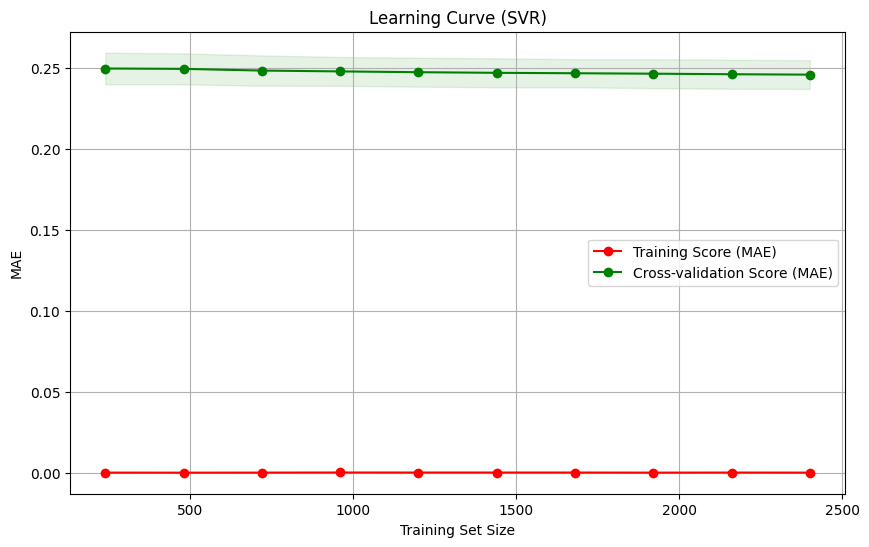

In [ ]:
best_svr = SVR(C=10.046492, gamma=0.936257, epsilon=0.000399)

train_sizes, train_scores, test_scores = learning_curve(
    best_svr, X, y, cv=5, scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
# 최적화된 하이퍼파라미터 설정
best_svr = SVR(C=10.046492, gamma=0.936257, epsilon=0.000399)

# 학습 곡선 계산 (MAE이므로 점수가 0에 가까울수록 좋습니다)
train_sizes, train_scores, test_scores = learning_curve(
    best_svr, X, y, cv=5, scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# 평균 및 표준편차 계산 (부호를 양수로 변환)
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Score (MAE)')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation Score (MAE)')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.title('Learning Curve (SVR)')
plt.xlabel('Training Set Size')
plt.ylabel('MAE')
plt.legend(loc='best')
plt.grid()
plt.show()